In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report

In [22]:
df = pd.read_excel('cancer patient data sets.xlsx')
df.head()

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,P1,33,1,2,4,5,4,3,2,2,...,3,4,2,2,3,1,2,3,4,Low
1,P10,17,1,3,1,5,3,4,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,P100,35,1,4,5,6,5,5,4,6,...,8,7,9,2,1,4,6,7,2,High
3,P1000,37,1,7,7,7,7,6,7,7,...,4,2,3,1,4,5,6,7,5,High
4,P101,46,1,6,8,7,7,7,6,7,...,3,2,4,1,4,2,4,2,3,High


In [23]:
df = df.drop('Patient Id', axis=1)
df.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


In [24]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,37.17,12.01,14.0,27.75,36.0,45.0,73.0
Gender,1000.0,1.40,0.49,1.0,1.00,1.0,2.0,2.0
Air Pollution,1000.0,3.84,2.03,1.0,2.00,3.0,6.0,8.0
Alcohol use,1000.0,4.56,2.62,1.0,2.00,5.0,7.0,8.0
Dust Allergy,1000.0,5.16,1.98,1.0,4.00,6.0,7.0,8.0
OccuPational Hazards,1000.0,4.84,2.11,1.0,3.00,5.0,7.0,8.0
Genetic Risk,1000.0,4.58,2.13,1.0,2.00,5.0,7.0,7.0
chronic Lung Disease,1000.0,4.38,1.85,1.0,3.00,4.0,6.0,7.0
Balanced Diet,1000.0,4.49,2.14,1.0,2.00,4.0,7.0,7.0
Obesity,1000.0,4.46,2.12,1.0,3.00,4.0,7.0,7.0


In [25]:
# Tabla equivalente a df.info()
info_table = pd.DataFrame(
    {
        "Non-Null Count": df.notna().sum(),
        "Null Count": df.isna().sum(),
        "Dtype": df.dtypes.astype(str),
    }
)
info_table.index.name = "Column"
display(info_table.reset_index())

,Column,Non-Null Count,Null Count,Dtype
0,Age,1000,0,int64
1,Gender,1000,0,int64
2,Air Pollution,1000,0,int64
3,Alcohol use,1000,0,int64
4,Dust Allergy,1000,0,int64
5,OccuPational Hazards,1000,0,int64
6,Genetic Risk,1000,0,int64
7,chronic Lung Disease,1000,0,int64
8,Balanced Diet,1000,0,int64
9,Obesity,1000,0,int64


Filas, columnas: (1000, 24)


Column,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1000 non-null   int64 
 1   Gender                    1000 non-null   int64 
 2   Air Pollution             1000 non-null   int64 
 3   Alcohol use               1000 non-null   int64 
 4   Dust Allergy              1000 non-null   int64 
 5   OccuPational Hazards      1000 non-null   int64 
 6   Genetic Risk              1000 non-null   int64 
 7   chronic Lung Disease      1000 non-null   int64 
 8   Balanced Diet             1000 non-null   int64 
 9   Obesity                   1000 non-null   int64 
 10  Smoking                   1000 non-null   int64 
 11  Passive Smoker            1000 non-null   int64 
 12  Chest Pain                1000 non-null   int64 
 13  Coughing of Blood         1000 non-null   int64 
 14  Fatigue                  

,count
Level,
High,365
Medium,332
Low,303


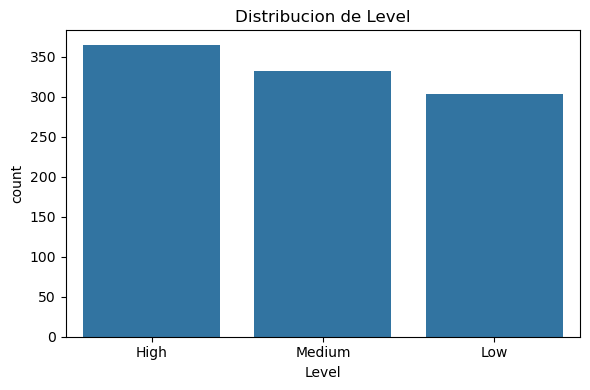

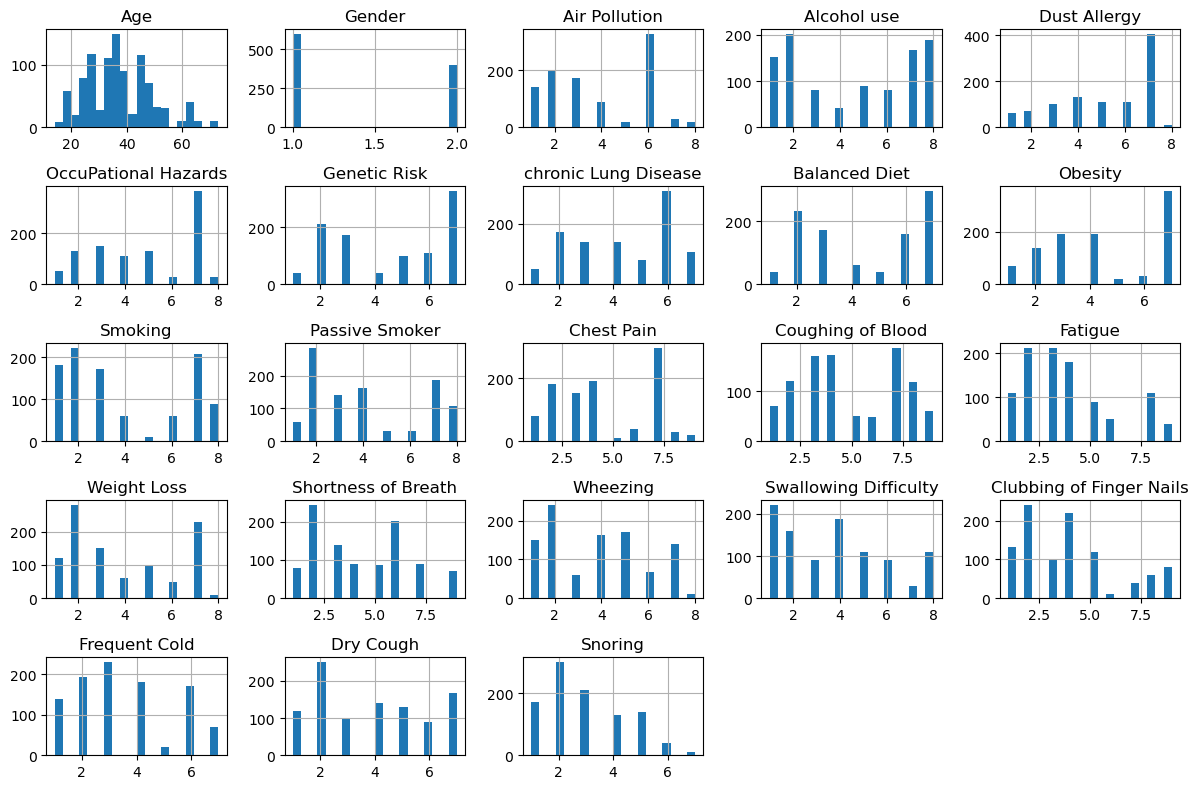

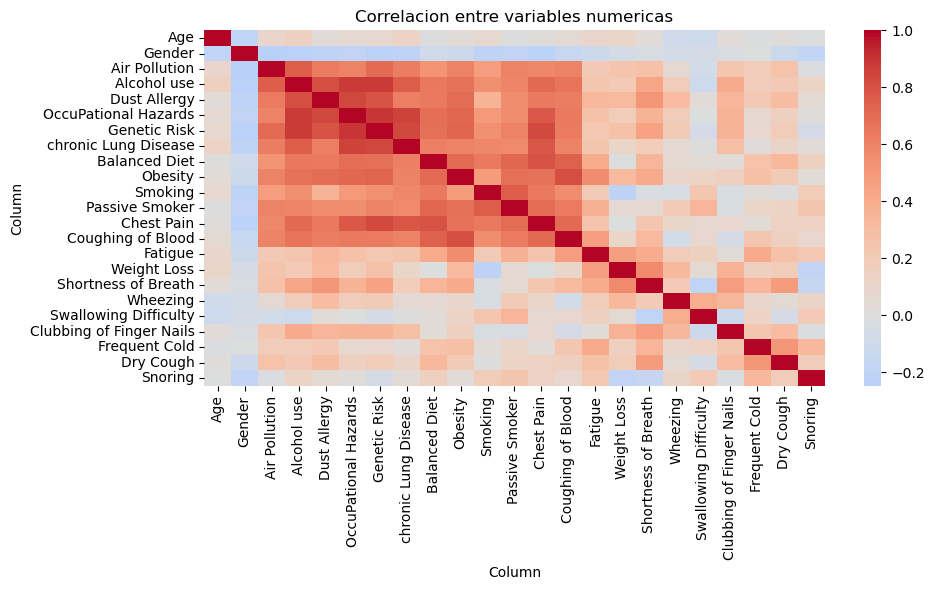

In [26]:
# EDA basico

print("Filas, columnas:", df.shape)

display(df.head())

df.info()

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Duplicated rows:", df.duplicated().sum())
missing

# Estadisticas descriptivas

df.describe(include="all").T

cat_cols = df.select_dtypes(exclude="number").columns
if len(cat_cols) > 0:
    for col in cat_cols:
        display(df[col].value_counts().rename_axis(col).to_frame("count"))
else:
    print("No categorical columns to summarize.")

plt.figure(figsize=(6, 4))
sns.countplot(x="Level", data=df, order=df["Level"].value_counts().index)
plt.title("Distribucion de Level")
plt.tight_layout()
plt.show()

num_cols = df.select_dtypes(include="number").columns
if len(num_cols) > 0:
    df[num_cols].hist(figsize=(12, 8), bins=20)
    plt.tight_layout()
    plt.show()

    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlacion entre variables numericas")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns to plot.")

In [6]:
df.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,0
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,1
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,2
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,2
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,2


In [6]:
df = df.drop('Age', axis=1)
df.head()

,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,1,2,4,5,4,3,2,2,4,3,...,3,4,2,2,3,1,2,3,4,0
1,1,3,1,5,3,4,2,2,2,2,...,1,3,7,8,6,2,1,7,2,1
2,1,4,5,6,5,5,4,6,7,2,...,8,7,9,2,1,4,6,7,2,2
3,1,7,7,7,7,6,7,7,7,7,...,4,2,3,1,4,5,6,7,5,2
4,1,6,8,7,7,7,6,7,7,8,...,3,2,4,1,4,2,4,2,3,2


In [7]:
X = df.drop('Level', axis=1)
Y = df['Level']

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier(random_state=42)


model.fit(x_train, y_train)


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(x_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0
